# Day 05：XOR 危机 —— AI 第一次寒冬的代码现场

> ❄️ 第一周 · AI 的初春与寒冬 · 第 5 天

1969 年，马文·明斯基（Marvin Minsky）证明了一个让整个 AI 领域绝望的事实：

> **单层感知机，永远无法解决 XOR 问题。**

这个发现直接让 AI 研究陷入长达十余年的寒冬。今天的科学家们终于找到了破局之法——但这要等到第 3-4 周。

**今天的任务**：
1. 深入理解 XOR 问题的本质
2. 用代码证明感知机在 XOR 上的无能为力
3. 从几何视角理解为什么「一条直线不够用」
4. 回顾 AI 第一次寒冬的历史

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

---

## 1. XOR 到底是什么？

XOR（异或，eXclusive OR）的逻辑：**两个输入不同时为 1，相同时为 0**

| X1 | X2 | AND | OR  | XOR |
|----|----|----|-----|-----|
| 0  | 0  | 0  | 0   | **0** |
| 0  | 1  | 0  | 1   | **1** |
| 1  | 0  | 0  | 1   | **1** |
| 1  | 1  | 1  | 1   | **0** |

注意 XOR 和 OR 的区别：
- OR 在 (1,1) 时输出 1
- XOR 在 (1,1) 时输出 0 —— **两个都为真，反而为假**

生活中 XOR 的例子：
- 一个开关控制一盏灯，拨一次亮，再拨一次灭
- 抢椅子游戏：只剩一把椅子两个人抢，不同的人抢到才算赢

In [2]:
# XOR 的数据
X_xor = torch.tensor([[0.0, 0.0],
                       [0.0, 1.0],
                       [1.0, 0.0],
                       [1.0, 1.0]])
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

# 看看四张「脸」分别长什么样
print("XOR 的四张面孔:\n")
for i in range(4):
    x = X_xor[i].tolist()
    y = int(y_xor[i].item())
    logic = "不同" if y == 1 else "相同"
    print(f"  ({int(x[0])}, {int(x[1])}) -> XOR = {y}  (两个输入{logic})")

XOR 的四张面孔:

  (0, 0) -> XOR = 0  (两个输入相同)
  (0, 1) -> XOR = 1  (两个输入不同)
  (1, 0) -> XOR = 1  (两个输入不同)
  (1, 1) -> XOR = 0  (两个输入相同)


---

## 2. 几何困境：为什么一条直线切不开？

让我们把 XOR 画在二维平面上，直观感受这个「不可能」的问题。

/var/folders/8j/y1d6rhz547zg9vsg7mw95nwc0000gn/T/ipykernel_75161/1777866473.py:9: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, x2, c=color, s=300, marker=marker,


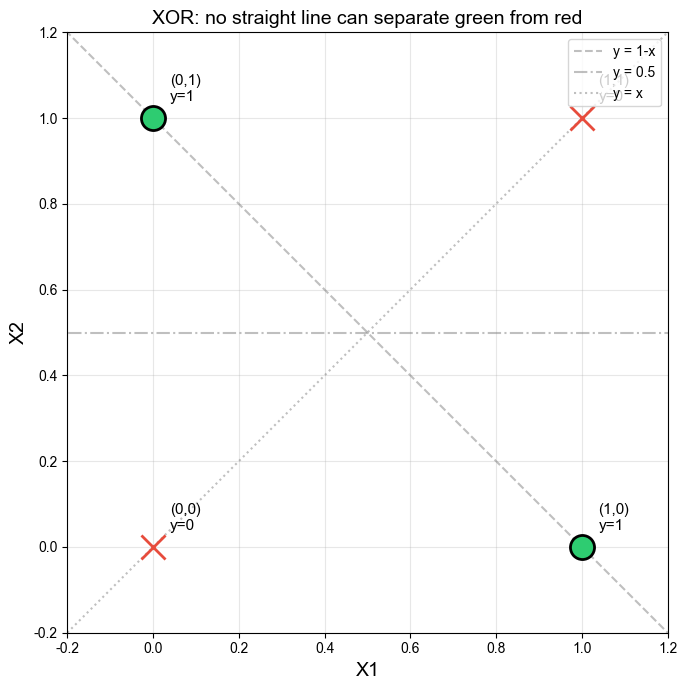

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

# 画数据点
for i in range(4):
    x1, x2 = X_xor[i].tolist()
    label = int(y_xor[i].item())
    color = '#2ecc71' if label == 1 else '#e74c3c'
    marker = 'o' if label == 1 else 'x'
    ax.scatter(x1, x2, c=color, s=300, marker=marker,
               edgecolors='black' if marker == 'o' else None, linewidth=2, zorder=5)
    ax.annotate(f'({int(x1)},{int(x2)})\ny={label}',
                (x1, x2), textcoords="offset points",
                xytext=(12, 12), fontsize=11, fontweight='bold')

# 画几条「失败的尝试」
x_range = np.linspace(-0.3, 1.3, 100)

attempts = [
    (lambda x: 1.0 - x,    'y = 1-x',     '--'),
    (lambda x: 0.5 + 0*x,  'y = 0.5',     '-.'),
    (lambda x: x,          'y = x',       ':'),
]

for func, label, linestyle in attempts:
    y_range = func(x_range)
    ax.plot(x_range, y_range, color='gray', linestyle=linestyle,
            alpha=0.5, linewidth=1.5, label=label)

ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_xlabel('X1', fontsize=14)
ax.set_ylabel('X2', fontsize=14)
ax.set_title('XOR: no straight line can separate green from red', fontsize=14)
ax.legend(loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 解读

图中灰色虚线是几种「尝试」——但你会发现：
- **y = 1-x**：把 (0,1) 和 (1,0) 放在一边，但两边都混了 Green 和 Red
- **y = 0.5**：把上下分开，但上面混了 Green 和 Red
- **y = x**：同理，总有混色

**根本不存在**一条直线能完美切割。

而感知机的全部能力，就是画一条直线——所以它**在数学原理上**就无法解决 XOR。

---

## 3. 代码实证：感知机的绝望

几何直觉很直观，但我们还是用代码**穷举验证**——无论怎么调整权重和偏置，单层感知机都解不开 XOR。

In [4]:
# 本notebook独立定义Perceptron类，固定2输入1输出（专为XOR验证）
class Perceptron:
    """完整的感知机"""
    def __init__(self, input_features_count=2):
        self.weights = torch.randn(input_features_count, 1)
        self.bias = torch.randn(1)
    
    def forward(self, inputs):
        z = torch.matmul(inputs, self.weights) + self.bias
        return (z > 0).float()

# 大量随机尝试：每次随机初始化权重，测试能否完美解决 XOR
num_attempts = 10000
success_count = 0

for attempt in range(num_attempts):
    neuron = Perceptron()
    predictions = neuron.forward(X_xor)
    
    if torch.all(predictions == y_xor):
        success_count += 1

print(f"随机尝试 {num_attempts} 次:")
print(f"  成功解决 XOR 的次数: {success_count}")
print(f"  成功率: {success_count/num_attempts*100:.2f}%")
print()
if success_count > 0:
    print('竟然成功了！（这在数学上是不可能的，除非宇宙出bug了）')
else:
    print('一次都没成功。这不是运气差——这是数学上的不可能。')

随机尝试 10000 次:
  成功解决 XOR 的次数: 0
  成功率: 0.00%

一次都没成功。这不是运气差——这是数学上的不可能。


### 为什么 10000 次都不行？

这不是「运气差」的问题。让我们从数学上证明：

假设存在权重 W1、W2 和偏置 b 使得感知机能正确分类 XOR：

```
(0,0) -> 0:  0*W1 + 0*W2 + b <= 0  =>  b <= 0
(0,1) -> 1:  0*W1 + 1*W2 + b >  0  =>  W2 + b > 0
(1,0) -> 1:  1*W1 + 0*W2 + b >  0  =>  W1 + b > 0
(1,1) -> 0:  1*W1 + 1*W2 + b <= 0  =>  W1 + W2 + b <= 0
```

由第2和第3个不等式：W2 > -b 且 W1 > -b，所以 W1 + W2 > -2b

由第1个不等式：b <= 0，所以 -2b >= 0

由第4个不等式：W1 + W2 <= -b

结合起来：-b < W1 + W2 <= -b，这意味着 W1 + W2 = -b

但第2和第3个不等式要求 W2 > -b 且 W1 > -b 严格成立，
所以 W1 + W2 > -2b >= 0，而 W1 + W2 = -b。
这要求 -b > -2b，即 b > 0，与 b <= 0 **矛盾**。

**证毕：不存在任何权重和偏置组合，能让单层感知机解决 XOR。**

---

## 4. 直观解释：为什么 XOR 与众不同？

让我们把 AND、OR、XOR 放在一起对比，看看问题的根源。

/var/folders/8j/y1d6rhz547zg9vsg7mw95nwc0000gn/T/ipykernel_75161/2448789166.py:18: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, x2, c=color, s=200, marker=marker,


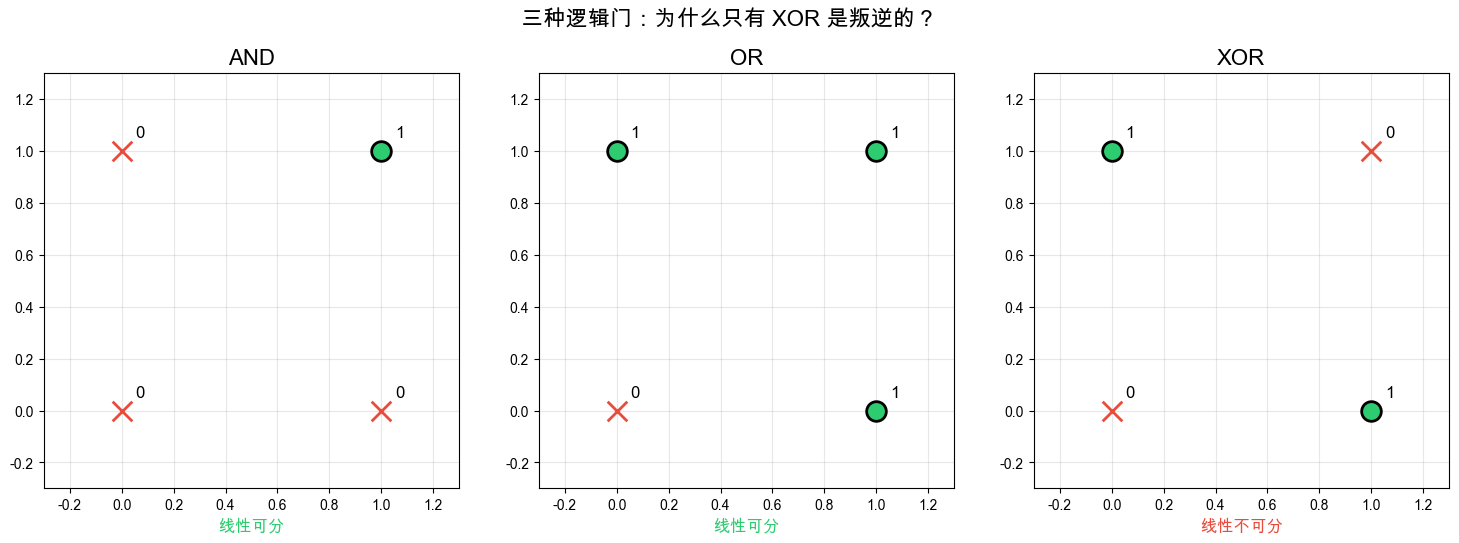

In [5]:
# 所有逻辑门的数据
gates = {
    'AND':  torch.tensor([[0.0], [0.0], [0.0], [1.0]]),
    'OR':   torch.tensor([[0.0], [1.0], [1.0], [1.0]]),
    'XOR':  torch.tensor([[0.0], [1.0], [1.0], [0.0]]),
}

X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (gate_name, y) in zip(axes, gates.items()):
    for i in range(4):
        x1, x2 = X[i].tolist()
        label = int(y[i].item())
        color = '#2ecc71' if label == 1 else '#e74c3c'
        marker = 'o' if label == 1 else 'x'
        ax.scatter(x1, x2, c=color, s=200, marker=marker,
                   edgecolors='black' if marker == 'o' else None, linewidth=2, zorder=5)
        ax.annotate(f'{label}', (x1, x2), textcoords="offset points",
                    xytext=(10, 10), fontsize=12, fontweight='bold')
    
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_title(gate_name, fontsize=16, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    solvable = '线性可分' if gate_name != 'XOR' else '线性不可分'
    solvable_color = '#2ecc71' if gate_name != 'XOR' else '#e74c3c'
    ax.text(0.5, -0.1, solvable, transform=ax.transAxes,
            ha='center', fontsize=12, color=solvable_color)

plt.suptitle('三种逻辑门：为什么只有 XOR 是叛逆的？', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 解读

- **AND**：三个红色挤在左下角，一个绿色在右上角 -> 一条线轻松切开
- **OR**：一个红色在左下角，三个绿色分散在其他地方 -> 同样轻松
- **XOR**：绿色和红色**对角交叉**——无论怎么画线，都会混色

XOR 的问题不在于数据量太少，而在于它的**拓扑结构**本身排斥线性分割。

这就是为什么——哪怕你给感知机无限的时间和数据——它也永远学不会 XOR。

---

## 5. 历史的回响：AI 第一次寒冬

1969 年，明斯基和帕佩尔特（Papert）出版了《感知机》一书，严格证明了：

> 单层感知机无法表达 XOR 这样的非线性可分函数。

这个结论的影响是毁灭性的：

- 投资者和政府机构撤回了对 AI 的资助
- 研究人员纷纷转行
- AI 从万众瞩目的明星变成了学术界的笑柄
- **这场寒冬持续了将近 15 年**（1969-1984）

讽刺的是，明斯基其实在书中提到了**多层网络**可能解决这个问题，但他没有给出具体方法。而当时的技术条件也不足以训练多层网络。

直到 1986 年，**反向传播算法（Backpropagation）** 的普及，才真正让多层网络的训练成为可能——这就是第 3-4 周我们将要学习的内容。

---

## 6. 一线希望：感知机的收敛定理

虽然 XOR 是坏消息，但感知机理论也有好消息——**感知机收敛定理**：

> 如果数据是线性可分的，感知机学习算法**保证**在有限步内找到正确的分类超平面。

让我们用代码验证这个定理：训练一个感知机去解决 AND 问题（线性可分），看看它是不是真的能自动找到正确的权重。

In [6]:
def train_perceptron(X, y, learning_rate=0.1, max_epochs=100):
    """
    感知机学习算法（Rosenblatt 规则）
    只适用于线性可分问题！
    """
    w = torch.randn(2, 1, requires_grad=False)
    b = torch.randn(1, requires_grad=False)
    
    for epoch in range(max_epochs):
        z = torch.matmul(X, w) + b
        predictions = (z > 0).float()
        
        if torch.all(predictions == y):
            print(f"第 {epoch+1} 轮收敛！找到完美权重。")
            return w, b, epoch + 1
        
        for i in range(len(X)):
            xi = X[i].reshape(1, -1)
            yi = y[i]
            pred = predictions[i]
            error = yi - pred
            w += learning_rate * error * xi.T
            b += learning_rate * error
    
    print(f"{max_epochs} 轮后仍未收敛（可能不是线性可分的）")
    return w, b, max_epochs

# 测试 AND 问题
print("=" * 40)
print("训练感知机解决 AND 问题")
print("=" * 40)
X_and = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_and = torch.tensor([[0.0], [0.0], [0.0], [1.0]])

w, b, epochs = train_perceptron(X_and, y_and)
print(f"最终权重: W = [{w[0].item():.3f}, {w[1].item():.3f}], b = {b.item():.3f}")

训练感知机解决 AND 问题
第 16 轮收敛！找到完美权重。
最终权重: W = [0.136, 0.124], b = -0.185


In [7]:
# 测试 XOR 问题
print("=" * 40)
print("尝试训练感知机解决 XOR 问题")
print("=" * 40)

X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

w, b, epochs = train_perceptron(X_xor, y_xor, max_epochs=500)
print(f"最终权重: W = [{w[0].item():.3f}, {w[1].item():.3f}], b = {b.item():.3f}")
print()
print("AND 是线性可分的，所以感知机收敛了。")
print("XOR 是线性不可分的，所以永远不会收敛。")
print("这就是感知机收敛定理的铁律。")

尝试训练感知机解决 XOR 问题
500 轮后仍未收敛（可能不是线性可分的）
最终权重: W = [-0.117, 0.079], b = -0.170

AND 是线性可分的，所以感知机收敛了。
XOR 是线性不可分的，所以永远不会收敛。
这就是感知机收敛定理的铁律。


---

## 第一周总结

回顾这五天，我们走过了感知机从诞生到困境的完整旅程：

| 天 | 内容 | 核心收获 |
|----|------|----------|
| Day 01 | 张量基础 | 深度学习的「通用货币」，矩阵乘法是核心运算 |
| Day 02 | 生物神经元 → 感知机 | 用数学模拟大脑的灵感来源 |
| Day 03 | 权重与偏置 | 「学习」= 找到最佳的 W 和 b |
| Day 04 | 线性分类边界 | 感知机 = 画一条直线；AND/OR 线性可分 |
| Day 05 | XOR 危机 | 线性不可分 -> 感知机彻底失败 -> AI 寒冬 |

### 感知机的极限

```
感知机能做的                    感知机不能做的
─────────────                ─────────────
AND 门                        XOR 门
OR 门                         任何线性不可分问题
简单的二分类                    图像识别
线性可分的数据                  语言理解
```

### 下周预告：破局之道

既然一条直线不够，那就：
1. **画多条线**（加入隐藏层）
2. **让线变弯**（非线性激活函数）
3. **让每条线都知道自己该往哪弯**（反向传播算法）

下周我们将见证 AI 是如何从这场寒冬中涅槃重生的。我们会亲手写出一个**带隐藏层的神经网络**，用反向传播训练它，完美解决 XOR 问题——而这一切，只用几行 PyTorch 代码。